# **Automated Annotation - Cell typist**


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import scanpy as sc
import anndata as ad
import pandas as pd
import os
import math

import celltypist
from celltypist import models

In [3]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

import numba
from numba.core.errors import NumbaDeprecationWarning, NumbaPendingDeprecationWarning

warnings.simplefilter("ignore", category=NumbaDeprecationWarning)

In [4]:
#setting verbosity and figure params
sc.settings.verbosity = 0 # show only error message
sc.settings.set_figure_params(
    dpi = 80,
facecolor = "white",
frameon = True,
)

In [6]:
import muon as mu

In [7]:
# threadpoolctl -> package used to limit the number of CPU 
# from threadpoolctl import threadpool_limits
# with threadpool_limits(limits=16, user_api='blas'):
      # codice indentato

In [8]:
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

Import data clusterized before the annotation of T cells

In [9]:
# import the data Covid 19 after regress out
adata = sc.read("/mnt/projects/labs/adata_metacells.h5")
adata

MuData object with n_obs × n_vars = 32404 × 20948
  2 modalities
    gex:	32404 x 20948
      obs:	'batch', 'condition', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'barcode', 'Effectorness', 'Effector_cells', 'Cell_state'
      var:	'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Cell_state_colors', 'Effector_cells_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    airr:	32404 x 0
      obs:	'batch'
      obsm:	'airr'

In [11]:
#sc.pl.umap(adata)

In [12]:
from scipy.sparse import csr_matrix
#adata.X = csr_matrix(adata.X)

In [13]:
# store raw counts in .layers['counts'] so we will still have acces later
#adata.layers["raw"] = adata.X
# set adata.X to the scarn-normalized log trans counts
#adata.X = adata.layers["scran_normalization"]

In [1]:
# Automated annotation -> cell typist
adata_celltypist = adata.copy()  # make a copy of our adata
adata_celltypist.X = adata.layers["raw"]  # set adata.X to raw counts
sc.pp.normalize_per_cell(adata_celltypist, counts_per_cell_after=10**4)  # normalize to 10,000 counts per cell
sc.pp.log1p(adata_celltypist)  
# make .X a matrix in order to make it dense
adata_celltypist.X = csr_matrix(adata_celltypist.X)
# make .X dense instead of sparse, for compatibility with celltypist:
adata_celltypist.X = adata_celltypist.X.toarray()

In [15]:
# download celltypist models for immune cells
models.download_models(
    force_update=True, model=["Immune_All_Low.pkl", "Immune_All_High.pkl"])

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 54
📂 Storing models in /mnt/home/montani/.celltypist/data/models
💾 Total models to download: 2
💾 Downloading model [1/2]: Immune_All_Low.pkl
💾 Downloading model [2/2]: Immune_All_High.pkl


In [12]:
# try the models
model_low = models.Model.load(model="Immune_All_Low.pkl") #finer annotation
model_high = models.Model.load(model="Immune_All_High.pkl") #coarser annotation

In [13]:
# to see which cell types includes
model_high.cell_types

array(['B cells', 'B-cell lineage', 'Cycling cells', 'DC', 'DC precursor',
       'Double-negative thymocytes', 'Double-positive thymocytes', 'ETP',
       'Early MK', 'Endothelial cells', 'Epithelial cells',
       'Erythrocytes', 'Erythroid', 'Fibroblasts', 'Granulocytes',
       'HSC/MPP', 'ILC', 'ILC precursor', 'MNP', 'Macrophages',
       'Mast cells', 'Megakaryocyte precursor',
       'Megakaryocytes/platelets', 'Mono-mac', 'Monocyte precursor',
       'Monocytes', 'Myelocytes', 'Plasma cells', 'Promyelocytes',
       'T cells', 'pDC', 'pDC precursor'], dtype=object)

In [14]:
# to see which cell types includes
model_low.cell_types

array(['Age-associated B cells', 'Alveolar macrophages', 'B cells',
       'CD16+ NK cells', 'CD16- NK cells', 'CD8a/a', 'CD8a/b(entry)',
       'CMP', 'CRTAM+ gamma-delta T cells', 'Classical monocytes',
       'Cycling B cells', 'Cycling DCs', 'Cycling NK cells',
       'Cycling T cells', 'Cycling gamma-delta T cells',
       'Cycling monocytes', 'DC', 'DC precursor', 'DC1', 'DC2', 'DC3',
       'Double-negative thymocytes', 'Double-positive thymocytes', 'ELP',
       'ETP', 'Early MK', 'Early erythroid', 'Early lymphoid/T lymphoid',
       'Endothelial cells', 'Epithelial cells', 'Erythrocytes',
       'Erythrophagocytic macrophages', 'Fibroblasts',
       'Follicular B cells', 'Follicular helper T cells', 'GMP',
       'Germinal center B cells', 'Granulocytes', 'HSC/MPP',
       'Hofbauer cells', 'ILC', 'ILC precursor', 'ILC1', 'ILC2', 'ILC3',
       'Intermediate macrophages', 'Intestinal macrophages',
       'Kidney-resident macrophages', 'Kupffer cells',
       'Large pre-B cell

In [15]:
# run the model -> coarse one
predictions_high = celltypist.annotate(adata_celltypist, model=model_high, majority_voting=True)

🔬 Input data has 13970 cells and 18314 genes
🔗 Matching reference genes in the model
🧬 5477 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [16]:
# Transform the predictions to adata to get the full output
predictions_high_adata = predictions_high.to_adata()

In [17]:
# copy the result to our original AnnData object
# conf score = confidence score -> filter out false positive
adata.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[adata.obs.index, "majority_voting"]
adata.obs["celltypist_conf_score_coarse"] = predictions_high_adata.obs.loc[adata.obs.index, "conf_score"]

In [18]:
# run the model -> finer one
predictions_low = celltypist.annotate(adata_celltypist, model=model_low, majority_voting=True)


🔬 Input data has 13970 cells and 18314 genes
🔗 Matching reference genes in the model
🧬 5477 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [19]:
predictions_low_adata = predictions_low.to_adata()

In [20]:
adata.obs["celltypist_cell_label_fine"] = predictions_low_adata.obs.loc[adata.obs.index, "majority_voting"]
adata.obs["celltypist_conf_score_fine"] = predictions_low_adata.obs.loc[adata.obs.index, "conf_score"]

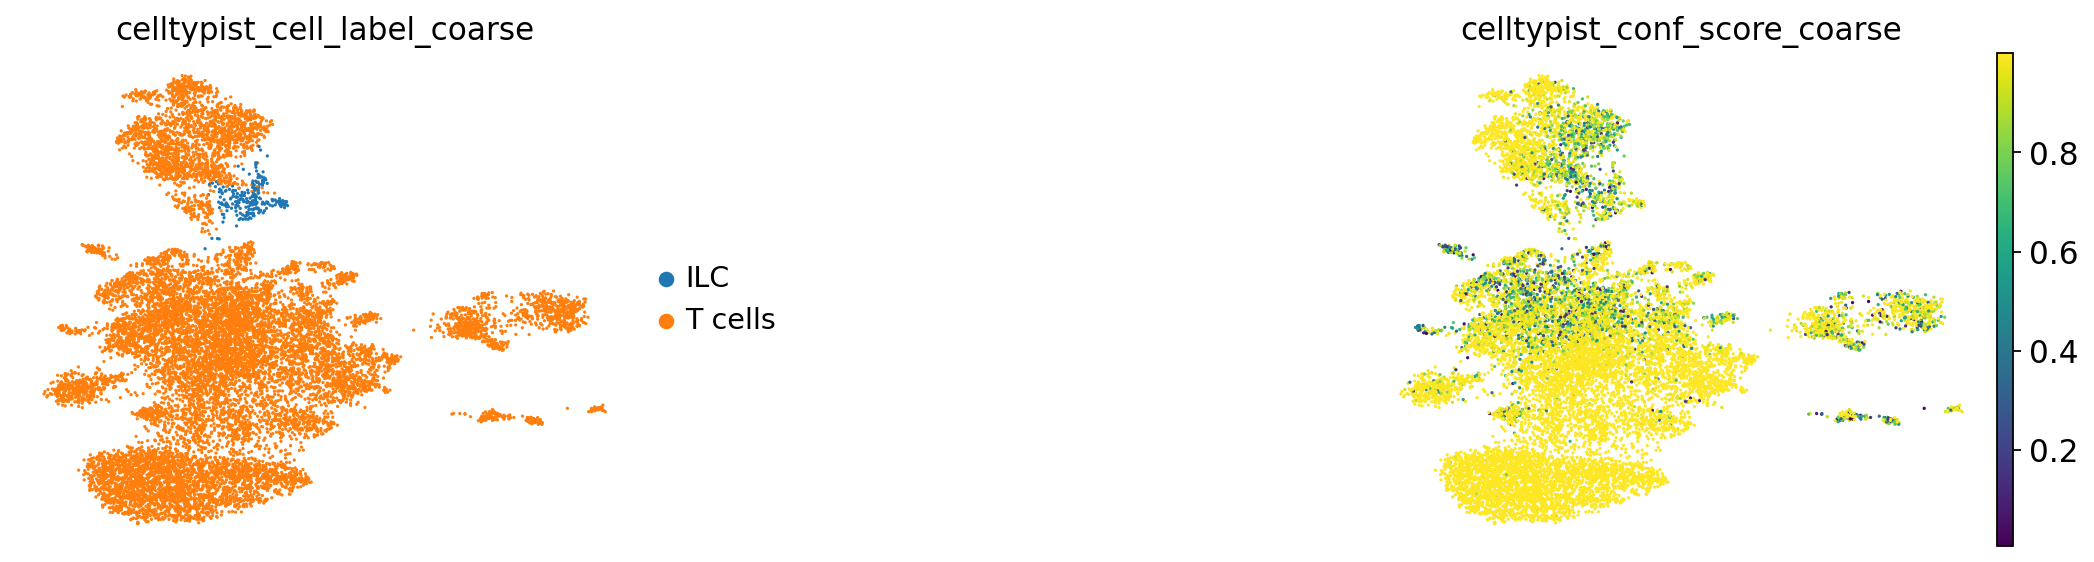

In [21]:
# plot coarse one
sc.pl.umap(
    adata,
    color=["celltypist_cell_label_coarse", "celltypist_conf_score_coarse"],
    frameon=False,
    sort_order=False,
    wspace=1)

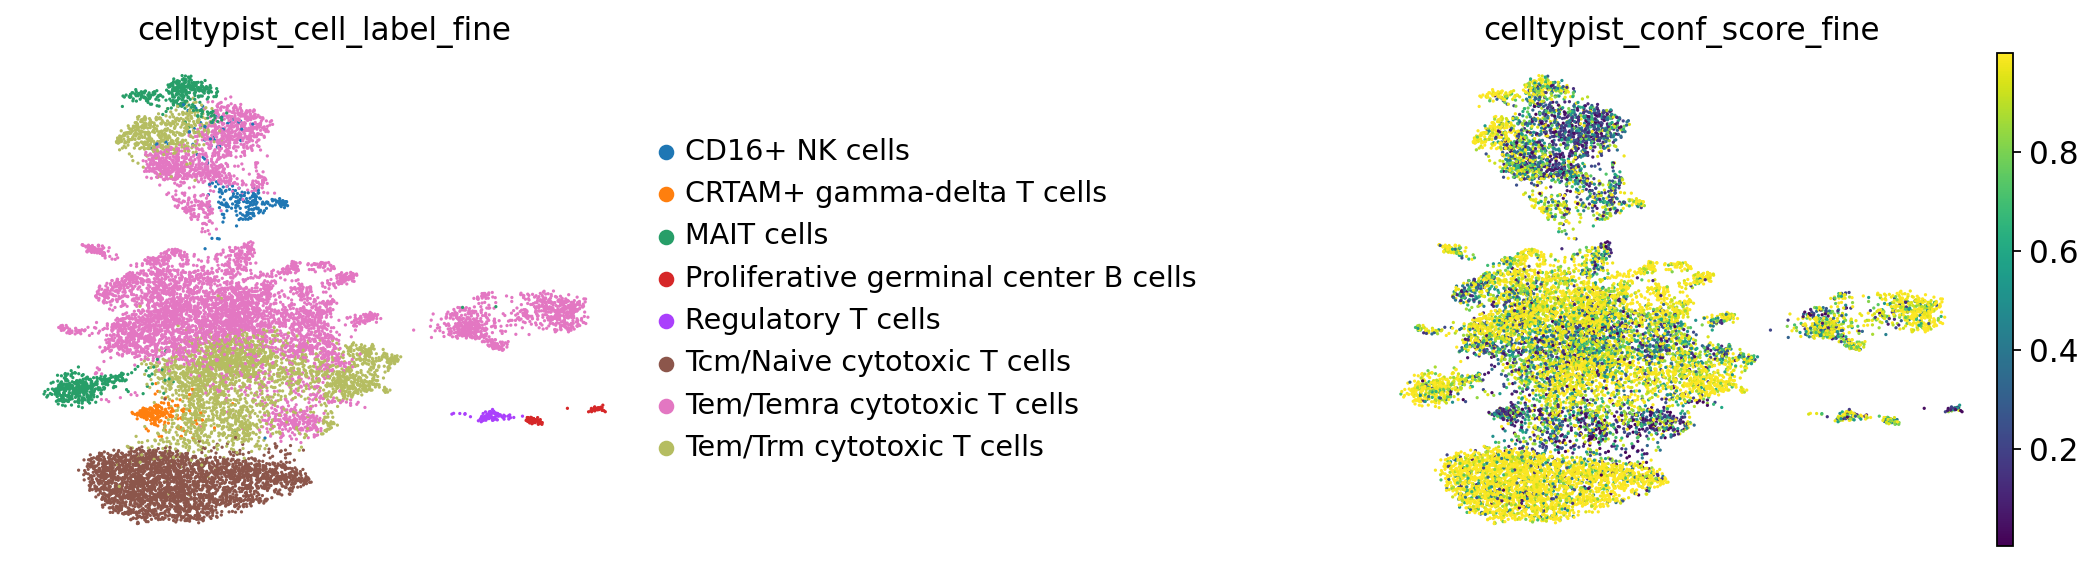

In [22]:
# plot finer one
sc.pl.umap(
    adata,
    color=["celltypist_cell_label_fine", "celltypist_conf_score_fine"],
    frameon=False,
    sort_order=False,
    wspace=1)

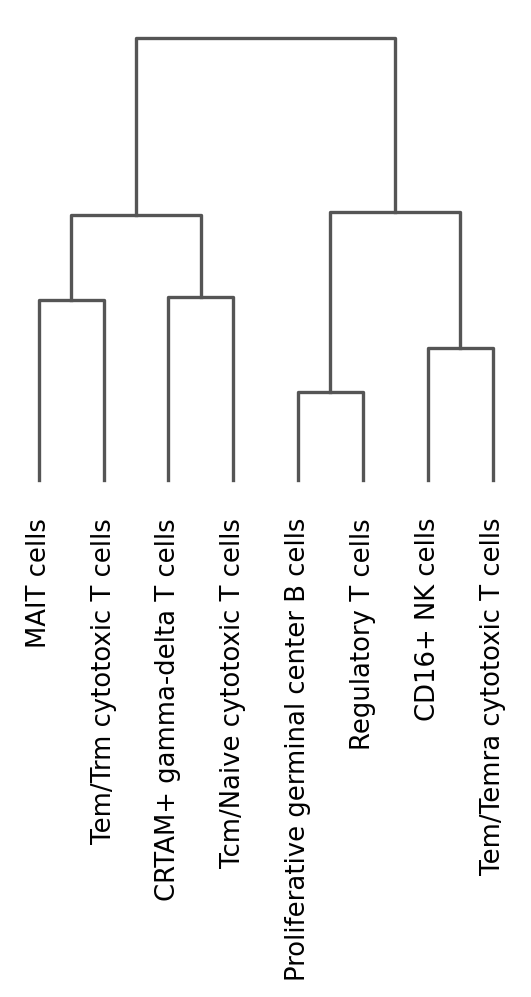

In [23]:
# plot dendogram
sc.pl.dendrogram(adata, groupby="celltypist_cell_label_fine")
plt.show()